In [9]:
!pip install pgmpy

  Using cached pgmpy-0.1.26-py3-none-any.whl.metadata (9.1 kB)
  Using cached statsmodels-0.14.4-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.2 kB)
  Using cached google_generativeai-0.8.4-py3-none-any.whl.metadata (4.2 kB)
  Using cached google_ai_generativelanguage-0.6.15-py3-none-any.whl.metadata (5.7 kB)
  Using cached google_auth-2.38.0-py2.py3-none-any.whl.metadata (4.8 kB)
  Using cached pydantic-2.10.6-py3-none-any.whl.metadata (30 kB)
  Using cached patsy-1.0.1-py2.py3-none-any.whl.metadata (3.3 kB)
  Using cached pyasn1_modules-0.4.1-py3-none-any.whl.metadata (3.5 kB)
  Using cached rsa-4.9-py3-none-any.whl.metadata (4.2 kB)
  Using cached httplib2-0.22.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached google_auth_httplib2-0.2.0-py2.py3-none-any.whl.metadata (2.2 kB)
  Using cached uritemplate-4.1.1-py2.py3-none-any.whl.metadata (2.9 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.27.2-cp313-cp313-macosx_11_0_arm64.

In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination
from tqdm import tqdm
from collections import defaultdict

import networkx as nx
import matplotlib.pyplot as plt




In [2]:
def load_data(directory):
    data = []
    files = glob.glob(directory + '/**/*.json', recursive=True)
    for filename in files:
        if "obj.json" in filename:
            with open(filename, 'r') as file:
                data.append(json.load(file))
    return data

directory = 'generated'
annotations_list = load_data(directory)

In [3]:
# len(annotations_list)
annotations_list[0]

{'world': {'floor': {'friction': '0.08143022135351674 0.07448288074562188 0.04940561410636971',
   'texture': 'flat',
   'rgba': '0.98 0.98 0.98 1',
   'specular': '0.751142',
   'shininess': '0.751142'},
  'camera': {'camera_name': 'camera',
   'lookat': [0.15480460188995426, -0.28325031489294206, 0.007817641497207217],
   'distance': 3.13410347131935,
   'azimuth': 171.86768203721104,
   'elevation': -31.59473581042311,
   'prev_lookat': [0.15480460188995426,
    -0.28325031489294206,
    0.007817641497207217],
   'prev_distance': 3.13410347131935,
   'alpha': 0.1},
  'lights': [{'pos': [0.3949501205493582,
     -0.34031328678388917,
     0.4145897116184435],
    'diffuse': '0.8328109523858105 0.9568414674583094 0.8417905925052512',
    'specular': '0.7478524612415072 0.6206347641924954 0.814503756573741',
    'cutoff': 67.88162876141635,
    'directional': False},
   {'pos': [0.37517053124751887, 0.7616956320393882, 0.18897459525439508],
    'diffuse': '0.8138601596056471 0.97755734

In [4]:
VELOCITY_BINS = [0, 0.5, 1.5, 3.0, 5.0, float('inf')]
VELOCITY_LABELS = ['v_low', 'low', 'medium', 'high', 'v_high']
ANG_VELOCITY_BINS = [0, 0.5, 1.5, float('inf')]
ANG_VELOCITY_LABELS = ['low', 'medium', 'high']
DURATION_BINS = [0, 1, 2.5, 5, 10, float('inf')]
DURATION_LABELS = ['v_short', 'short', 'medium', 'long', 'v_long']
FLOOR_FRICTION_BINS = [0, 0.05, 0.1, 0.2, float('inf')]
FLOOR_FRICTION_LABELS = ['very_low', 'low', 'medium', 'high']

def discretize_floor_friction(friction_value):
    if friction_value < 0.05:
        return 'very_low'
    elif friction_value < 0.1:
        return 'low'
    elif friction_value < 0.2:
        return 'medium'
    else:
        return 'high'
        

def create_training_dataset(annotations_list):
    video_data = []
    
    for annotation in tqdm(annotations_list, desc="Processing videos"):
        duration_seconds = annotation['frames'][-1]['time']
        num_objects = len(annotation['objects'])
        
        floor_friction = list(map(float, annotation['world']['floor']['friction'].split(" ")))
        floor_friction_mean = np.mean(floor_friction)
        floor_friction_cat = discretize_floor_friction(floor_friction_mean)

        for frame in annotation['frames']:
            frame_time = frame['time']
            frame_progress = frame_time / duration_seconds if duration_seconds > 0 else 0
            
            for obj_id, obj_data in frame['objects'].items():
                obj_info = next(obj for obj in annotation['objects'] if obj['id'] == obj_id)
                
                obj_friction = list(map(float, obj_info['friction'].split()))
                obj_friction_mean = np.mean(obj_friction)
                velocity = np.linalg.norm(obj_data['velocity'])
                ang_velocity = np.linalg.norm(obj_data['angular_velocity'])
                
                row = {
                    'duration_seconds': duration_seconds,
                    'num_objects': num_objects,
                    'floor_friction_mean': floor_friction_mean,
                    'floor_friction_cat': floor_friction_cat,
                    'floor_texture': annotation['world']['floor']['texture'],
                    'shape': obj_info['shape'],
                    'material': obj_info['material'],
                    'elasticity': obj_info['elasticity'],
                    'obj_friction_mean': obj_friction_mean,
                    'velocity_raw': velocity,
                    'ang_velocity_raw': ang_velocity,
                    'mode': obj_info['mode'],
                    'in_frame': int(obj_data['bbox'][1][0] > 0 and obj_data['bbox'][1][1] > 0)
                }
                video_data.append(row)
    
    return pd.DataFrame(video_data)



In [5]:
def train_unified_model(df):
    df['velocity'] = pd.cut(df['velocity_raw'], bins=VELOCITY_BINS, labels=VELOCITY_LABELS)
    df['ang_velocity'] = pd.cut(df['ang_velocity_raw'], bins=ANG_VELOCITY_BINS, labels=ANG_VELOCITY_LABELS)
    df['duration'] = pd.cut(df['duration_seconds'], bins=DURATION_BINS, labels=DURATION_LABELS)
    df['floor_friction_cat'] = pd.Categorical(df['floor_friction_cat'], categories=FLOOR_FRICTION_LABELS)
    

    model = BayesianNetwork([
        ('num_objects', 'duration'),
        ('floor_friction_cat', 'duration'),
        ('shape', 'in_frame'),
        ('material', 'mode'),
        ('mode', 'duration'),
        ('velocity', 'in_frame'),
        ('mode', 'in_frame'),
        ('ang_velocity', 'in_frame'),
        ('in_frame', 'duration'),
    ])

    model.fit(df, estimator=BayesianEstimator)
    return model


In [6]:
def prepare_multi_object_evidence(input_data):
    floor_friction_mean = round(float(np.mean(list(map(float, input_data['floor_friction'].split(' '))))), 4)
    floor_friction_cat = discretize_floor_friction(floor_friction_mean)
   
    evidence = {
        'num_objects': min(len(input_data['shape']), 5),  
        'floor_friction_cat': floor_friction_cat
    }
    
    aggregators = {
        'shapes': defaultdict(int),
        'materials': defaultdict(int),
        'modes': defaultdict(int),
        'velocities': [],
        'ang_velocities': [],
        'obj_frictions': []
    }
    
    for i in range(len(input_data['shape'])):
        aggregators['shapes'][input_data['shape'][i]] += 1
        aggregators['materials'][input_data['material'][i]] += 1
        aggregators['modes'][input_data['mode'][i]] += 1
        
        vel_norm = round(float(np.linalg.norm(input_data['velocity'][i])), 4)
        ang_vel_norm = round(float(np.linalg.norm(input_data['angular_velocity'][i])), 4)
        velocity_cat = pd.cut([vel_norm], bins=VELOCITY_BINS, labels=VELOCITY_LABELS)[0]
        ang_velocity_cat = pd.cut([ang_vel_norm], bins=ANG_VELOCITY_BINS, labels=ANG_VELOCITY_LABELS)[0]
        
        aggregators['velocities'].append(velocity_cat)
        aggregators['ang_velocities'].append(ang_velocity_cat)

        aggregators['obj_frictions'].append(
            round(float(np.mean(
                list(map(float, input_data['obj_friction'][i].split(' ')))
            )), 4)
        )

    evidence.update({
        'shape': max(aggregators['shapes'], key=aggregators['shapes'].get),
        'material': max(aggregators['materials'], key=aggregators['materials'].get),
        'mode': max(aggregators['modes'], key=aggregators['modes'].get),
        'velocity': max(set(aggregators['velocities']), key=aggregators['velocities'].count),
        'ang_velocity': max(set(aggregators['ang_velocities']), key=aggregators['ang_velocities'].count),
        'obj_friction_mean': round(float(np.mean(aggregators['obj_frictions'])), 4)
    })
    
    return evidence

def validate_evidence(evidence, model):
    valid_evidence = {}
    required_nodes = set(model.nodes()) - {'duration', 'in_frame'}  # Output nodes
    
    for node in required_nodes:
        if node not in evidence:
            raise ValueError(f"Missing required evidence for node: {node}")
        
        # Convert to correct type
        if node in ['num_objects']:
            valid_evidence[node] = int(evidence[node])
        elif node in ['floor_friction_mean', 'obj_friction_mean']:
            valid_evidence[node] = round(float(evidence[node]), 4)
        else:
            valid_evidence[node] = str(evidence[node])  # Categorical variables
            
    return valid_evidence



def predict_duration_multi_object(model, input_data):
    try:
        raw_evidence = prepare_multi_object_evidence(input_data)

        model_nodes = set(model.nodes())
        evidence = {k: v for k, v in raw_evidence.items() if k in model_nodes}

        required_nodes = model_nodes - {'duration', 'in_frame'}
        missing_nodes = required_nodes - set(evidence.keys())
        if missing_nodes:
            raise ValueError(f"Missing evidence for nodes: {missing_nodes}")
        
        infer = VariableElimination(model)
        result = infer.query(
            variables=['duration'],
            evidence=evidence
        )
        
        return {
            'status': 'success',
            'prediction': result,
            'used_evidence': evidence
        }
        
    except Exception as e:
        return {
            'status': 'error',
            'message': str(e),
            'input_data': input_data,
            'processed_evidence': raw_evidence if 'raw_evidence' in locals() else None,
            'model_nodes': list(model.nodes()) if 'model' in locals() else None
        }

def plot_network_structure(model):
    G = nx.DiGraph(model.edges())
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=2000, arrows=True)
    plt.title("Bayesian Network Structure")
    plt.show()


In [7]:
df = create_training_dataset(annotations_list)

Processing videos: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:02<00:00, 233.10it/s]


In [8]:
df.head()

,duration_seconds,num_objects,floor_friction_mean,floor_friction_cat,floor_texture,shape,material,elasticity,obj_friction_mean,velocity_raw,ang_velocity_raw,mode,in_frame
0,5.0005,4,0.06844,low,flat,ball,plastic,0.606,0.400000,1.772506,0.981871,sliding,1
1,5.0005,4,0.06844,low,flat,block,rubber,0.872,0.863333,4.952635,0.916517,collision,1
2,5.0005,4,0.06844,low,flat,ball,rubber,0.917,0.986667,1.441356,1.540119,sliding,1
3,5.0005,4,0.06844,low,flat,cube,rubber,1.000,0.973333,3.525838,0.911873,collision,1
4,5.0005,4,0.06844,low,flat,ball,plastic,0.606,0.400000,1.656849,6.391740,sliding,1


In [9]:
model = train_unified_model(df)
model.save('phlop_bayesian_network.pkl')


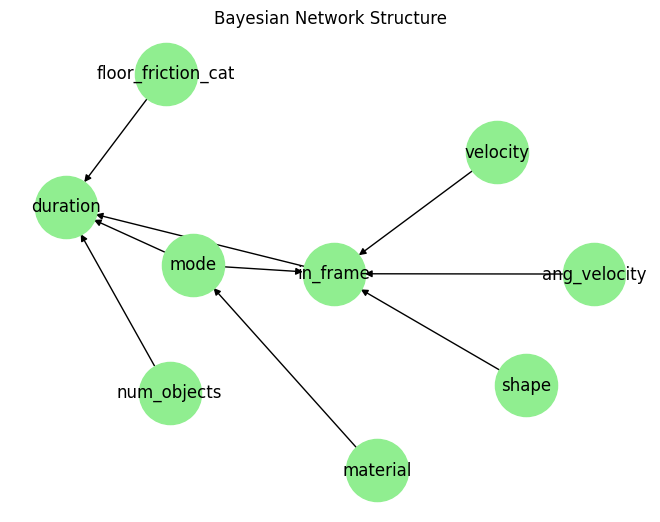

In [17]:
plot_network_structure(model)

In [11]:
test_scenario = {
    'shape': ["cube", "ball"],
    'material': ['rubber', "metal"],
    'mode': ['collision', 'sliding'],
    'velocity': [[1.2, -0.3, 0.1], [0.8, -0.2, 0.05]],
    'angular_velocity': [[0.4, 0.1, -0.2], [0.1, 0.05, -0.1]],
    'floor_friction': "0.1 0.2 0.15",
    'obj_friction': ["0.8 0.7 0.9", "0.5 0.6 0.55"]
}

# First verify model structure
print("Model nodes:", model.nodes())


result = predict_duration_multi_object(model, test_scenario)

if 'prediction' in result:
    print("Prediction successful:")
    print(result['prediction'])
    print("\nUsed evidence:")
    print(result['used_evidence'])
else:
    print(result)
    print("Prediction failed:")
    # print(result['error'])
    # print("\nDebug info:")
    # print(result['input_data'])
    # print(result['processed_evidence'])

Model nodes: ['num_objects', 'duration', 'floor_friction_cat', 'shape', 'in_frame', 'material', 'mode', 'velocity', 'ang_velocity']
Prediction successful:
+----------------+-----------------+
| duration       |   phi(duration) |
+================+=================+
| duration(long) |          1.0000 |
+----------------+-----------------+

Used evidence:
{'num_objects': 2, 'floor_friction_cat': 'medium', 'shape': 'cube', 'material': 'rubber', 'mode': 'collision', 'velocity': 'low', 'ang_velocity': 'low'}


Marginal probability for 'duration':
+----------------+-----------------+
| duration       |   phi(duration) |
+================+=================+
| duration(long) |          1.0000 |
+----------------+-----------------+


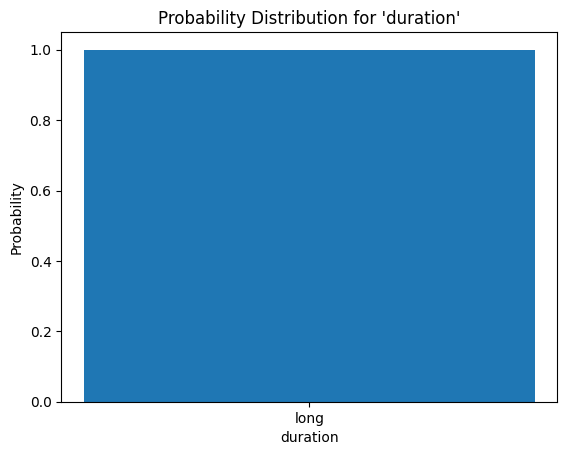

In [16]:

infer = VariableElimination(model)


evidence = {
    'mode': 'collision',
    'floor_friction_cat': 'medium',
    'velocity': 'low',
    'shape': 'ball',
    'material': 'rubber',
    'num_objects': 2,
    'ang_velocity': 'low'
}


duration_prob = infer.query(variables=['duration'], evidence=evidence)
# duration_prob = result[prediction]
print("Marginal probability for 'duration':")
print(duration_prob)


def plot_distribution(query_result, node_name):
    values = query_result.values
    states = query_result.state_names[node_name]
    
    # Create a bar plot for the probability distribution
    plt.bar(states, values)
    plt.xlabel(node_name)
    plt.ylabel("Probability")
    plt.title(f"Probability Distribution for '{node_name}'")
    plt.show()


plot_distribution(duration_prob, 'duration')
